In [2]:
%load_ext autoreload
%autoreload 2

# Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import fetch_daily_data
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns, calculate_MA_returns, calculate_relative_volume
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models
from scipy import stats
import statsmodels.api as sm
from utils.helpers import constrained_linear_regression, gmean, hmean, compute_r2, normalize_weights
import json


# UTILITY FUNCTIONS

In [4]:
def days_difference(date1, date2):
    fmt = "%Y-%m-%d"
    d1 = datetime.datetime.strptime(date1, fmt)
    d2 = datetime.datetime.strptime(date2, fmt)
    return abs((d2 - d1).days)

# Parameters

In [5]:
LOOKFORWARD_PERIOD = 21
REBALANCE_PERIOD = 21
LOOKBACK_PERIODS=[21, 100, 252]
LAG_PERIODS = [0, 21]
CURRENT_CAPITAL = 93204


COVAR_LOOKBACK_PERIOD = 252
HISTORY_LOOKBACK_PERIOD = 252 * 2

CURRENT_DATE = datetime.datetime.now().date()
CURRENT_DATE = CURRENT_DATE.strftime("%Y-%m-%d")

# Load Data

In [6]:
tickers_to_fetch = [
    'IB01.L', 
    'SHV', 
    'SPY', 
    'TLT', 
    'GLD', 
    '^VIX', 
    '^GVZ', 
    'PPLT', 
    'URA', 
    'DBA', 
    'EEM', 
    'LQD', 
    'IBIT', 
    'USO', 
    'CPER', 
    'OPEN',
    'UURAF',
    'UUUU',
    'ABAT',
    'LAC',
    'TMC',
    'MP',
    'UPRO',
    'TMF',
    'CSPX.L',
    'U',
    'SMR',
    'OKLO',
    'LEU',
    'BWXT',
    'GOOG',
    'MSFT',
    'SHNY',
    'HOOD',
    'ETHA',
    'IEF',
]

price_data = dict()
for ticker in tqdm(tickers_to_fetch):
    # Check if data already exists locally
    if os.path.exists(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv')):
        df = pd.read_csv(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv'), index_col=0, parse_dates=True)
    else:
        df = fetch_daily_data(ticker)
        # save data locally
        df.to_csv(os.path.join('data', 'price', f'{ticker}_{CURRENT_DATE}.csv'))
    price_data[ticker] = df


for ticker in price_data:
    print(ticker, price_data[ticker].index.to_list()[0], price_data[ticker].index.to_list()[-1])
    # display(price_data[ticker])

  0%|          | 0/36 [00:00<?, ?it/s]

IB01.L 2019-02-20 00:00:00 2025-11-07 00:00:00
SHV 2007-01-11 00:00:00 2025-11-07 00:00:00
SPY 1993-01-29 00:00:00 2025-11-07 00:00:00
TLT 2002-07-30 00:00:00 2025-11-07 00:00:00
GLD 2004-11-18 00:00:00 2025-11-07 00:00:00
^VIX 1990-01-02 00:00:00 2025-11-07 00:00:00
^GVZ 2008-06-03 00:00:00 2025-11-07 00:00:00
PPLT 2010-01-08 00:00:00 2025-11-07 00:00:00
URA 2010-11-05 00:00:00 2025-11-07 00:00:00
DBA 2007-01-05 00:00:00 2025-11-07 00:00:00
EEM 2003-04-14 00:00:00 2025-11-07 00:00:00
LQD 2002-07-30 00:00:00 2025-11-07 00:00:00
IBIT 2024-01-11 00:00:00 2025-11-07 00:00:00
USO 2006-04-10 00:00:00 2025-11-07 00:00:00
CPER 2011-11-15 00:00:00 2025-11-07 00:00:00
OPEN 2020-06-18 00:00:00 2025-11-07 00:00:00
UURAF 2010-01-05 00:00:00 2025-11-07 00:00:00
UUUU 2007-03-19 00:00:00 2025-11-07 00:00:00
ABAT 2016-02-24 00:00:00 2025-11-07 00:00:00
LAC 2023-10-02 00:00:00 2025-11-07 00:00:00
TMC 2021-09-10 00:00:00 2025-11-07 00:00:00
MP 2020-06-22 00:00:00 2025-11-07 00:00:00
UPRO 2009-06-25 00:0

# Current Portfolio

CAGR:                   13.05%   (ref: 23.57%)
Volatility:             9.65%    (ref: 21.95%)
Sharpe Ratio:           1.35     (ref: 1.07)
Max Drawdown:          -4.86%    (ref: -12.05%)
Total Returns:          11.23%
Total PnL:             $8995.28


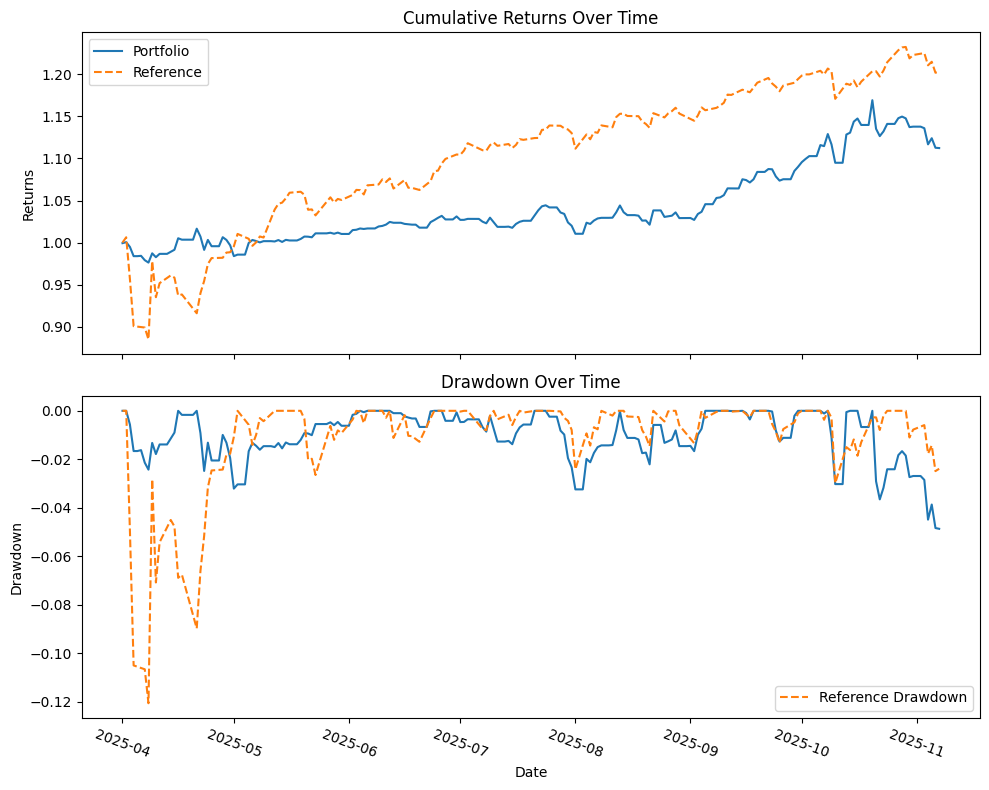

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital, holdings

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252, ref_df=None):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    if ref_df is not None:
        ref_df.index = pd.to_datetime(ref_df.index)
        ref_prices = ref_df.loc[ref_df.index.isin(portfolio_value.index), 'adjclose']
        ref_returns = ref_prices / ref_prices.shift(1) - 1
        ref_cagr = (ref_prices.iloc[-1] / ref_prices.iloc[0]) ** (trading_days / total_days) - 1
        ref_vol = ref_returns.std() * np.sqrt(trading_days)
        ref_sharpe = ref_cagr / ref_vol
        ref_rolling_max = (ref_prices / ref_prices.iloc[0]).cummax()
        ref_drawdown = (ref_prices / ref_prices.iloc[0] - ref_rolling_max) / ref_rolling_max
        ref_max_dd = ref_drawdown.min()


    print(f'CAGR:                   {cagr:.2%}   (ref: {ref_cagr:.2%})' if ref_df is not None else f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}    (ref: {ref_vol:.2%})' if ref_df is not None else f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}     (ref: {ref_sharpe:.2f})' if ref_df is not None else f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}    (ref: -{-ref_max_dd:.2%})' if ref_df is not None else f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital, ref_df=None):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max

    # If reference dataframe is provided, adjust ref_df to same date range as portfolio_value
    if ref_df is not None:
        ref_df.index = pd.to_datetime(ref_df.index)
        ref_prices = ref_df.loc[ref_df.index.isin(portfolio_value.index), 'adjclose']
        ref_cumulative_returns = ref_prices / ref_prices.iloc[0]
        ref_rolling_max = ref_cumulative_returns.cummax()
        ref_drawdown = (ref_cumulative_returns - ref_rolling_max) / ref_rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values, label='Portfolio')
    if ref_df is not None:
        ax1.plot(ref_cumulative_returns.index, ref_cumulative_returns.values, label='Reference', linestyle='--')
        ax1.legend()
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    if ref_df is not None:
        ax2.plot(ref_drawdown.index, ref_drawdown.values, label='Reference Drawdown', linestyle='--')
        ax2.legend()
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')

# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = price_data.copy()
port_val, invested_cap, holdings = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap, ref_df=price_data_dict.get('SPY'))
plot_portfolio_and_drawdown(port_val, invested_cap, ref_df=price_data_dict.get('SPY'))
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')




In [8]:
current_holdings = {
    ticker: holdings[ticker].iloc[-1] for ticker in holdings if holdings[ticker].iloc[-1] != 0
}

current_holdings
df_view = pd.DataFrame.from_dict(current_holdings, orient='index', columns=['quantity'])
df_view['price'] = [price_data_dict[ticker]['close'].iloc[-1] for ticker in df_view.index]
df_view['value'] = df_view['quantity'] * df_view['price']
df_view['% of portfolio'] = df_view['value'] / CURRENT_CAPITAL * 100
df_view.sort_values('value', ascending=False, inplace=True)
print(f"% of portfolio: {sum(df_view['% of portfolio']):.2f}%")
df_view

% of portfolio: 97.14%


,quantity,price,value,% of portfolio
LQD,191.0,110.709999,21145.609825,22.687449
UPRO,161.0,112.050003,18040.050491,19.355447
SPY,14.0,670.969971,9393.579590,10.078516
TLT,92.0,89.570000,8240.439972,8.841294
CSPX.L,11.0,711.559998,7827.159973,8.397880
SHV,45.0,110.230003,4960.350151,5.322036
EEM,89.0,54.549999,4854.949932,5.208950
GLD,13.0,368.309998,4788.029968,5.137151
SHNY,39.0,109.980003,4289.220131,4.601970
MSFT,3.0,496.820007,1490.460022,1.599137


# Portfolio Settings

In [9]:
# CORE PORTFOLIO
core_portfolio_ticker_list = [
    'CSPX.L',
    'LQD',
    'TLT',
    'EEM',
    'GLD',
]
core_portfolio_allocation = 0.5

SPY_mom_allocation = 0.1

leveraged_portfolio_orders = dict()
UPRO_vol_allocation = 0.2
SHNY_vol_allocation = 0.1


# STOCK-PICK PORTFOLIO
stock_pick_portfolio_ticker_list = [
    'URA', 
    'ETHA',
    'GOOG',
    'MSFT',
    'HOOD',
]
stock_pick_portfolio_allocation = 0.1

assert 0.99 < np.sum([
    core_portfolio_allocation,
    SPY_mom_allocation,
    UPRO_vol_allocation,
    SHNY_vol_allocation,
    stock_pick_portfolio_allocation,
]) < 1.01, "Allocations must sum to 1"

combined_target_allocation = dict()
combined_orders = dict()

with open('STATUS_leveraged_port.json', 'r') as f:
    status_data = json.load(f)
last_update_date = status_data['UPRO']['date']
days_since_update = days_difference(last_update_date, CURRENT_DATE)
if days_since_update < 25:
    raise ValueError(f"Data is up to date as of {last_update_date}. No need to run the script.")

ValueError: Data is up to date as of 2025-10-18. No need to run the script.

# CORE PORTFOLIO

## Allocation based on HRP

### Utility Function

In [ ]:
def allocation_func(
    ticker_list,
    data,
    historical_period, 
    current_date,
    covariance_matrix_lookback,
    verbose=False
):
    #################################################################
    # Correlation Optimization
    # Use HRP to optimize for correlation between assets
    #################################################################
    
    df_combined = pd.DataFrame()
    for ticker in ticker_list:
        df_data = data[ticker].copy()
        df_data = df_data[df_data.index <= current_date].copy()
        df_data = df_data.iloc[-historical_period:]
        df_data['returns'] = df_data['close'].pct_change()
        df_combined[ticker] = df_data['returns']
    df_combined.dropna(inplace=True)

    # Covariance Matrix with Exponentially Weighted Moving Average
    ewma_cov = risk_models.exp_cov(df_combined, returns_data=True, span=covariance_matrix_lookback)
    
    # Convariance Matrix with Ledoit Wolf shrinkage
    ledoit_wolf_cov = risk_models.CovarianceShrinkage(
        prices=df_combined.iloc[-covariance_matrix_lookback:], 
        returns_data=True
    ).ledoit_wolf()

    # Final Covariance Matrix is mean of EWMA and Ledoit Wolf
    cov = (ledoit_wolf_cov + ewma_cov) / 2

    # HRP to generate asset allocation weights
    hrpopt = HRPOpt(
        cov_matrix=cov
    )
    asset_allocation_weights = hrpopt.optimize()
    if verbose:
        for ticker in asset_allocation_weights:
            print(f"{ticker}: {asset_allocation_weights[ticker]:.2%}")
    

    


    #################################################################
    # Combination of all optimizations
    #################################################################
    final_weights = asset_allocation_weights

    return final_weights



### Get Allocation

In [ ]:
allocations = allocation_func(
    core_portfolio_ticker_list,
    price_data,
    historical_period=252*2, 
    current_date=CURRENT_DATE,
    covariance_matrix_lookback=COVAR_LOOKBACK_PERIOD,
    verbose=True,
)

allocations

CSPX.L: 16.15%
EEM: 10.58%
GLD: 8.66%
LQD: 46.75%
TLT: 17.86%


OrderedDict([('CSPX.L', np.float64(0.16150672493323875)),
             ('EEM', np.float64(0.10582151612154249)),
             ('GLD', np.float64(0.08655907043142942)),
             ('LQD', np.float64(0.46753394031758166)),
             ('TLT', np.float64(0.17857874819620767))])

### Allocate

In [ ]:
capital = core_portfolio_allocation * CURRENT_CAPITAL
core_portfolio_orders = dict()

for ticker in core_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = allocations[ticker] * capital
    
    current_price = price_data[ticker]['close'].iloc[-1]
    
    target_holding = int(capital_allocated / current_price)
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.75) + 1

    print(f"Capital_allocated = {capital_allocated:.2f} ({allocations[ticker]:.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    core_portfolio_orders[ticker] = target_order
    combined_orders[ticker] = target_order
    


-----------------------
CSPX.L
Capital_allocated = 7526.54 (16.15%)
Target holding:   = 10      (7526.54 / 727.26)
Target order:     = 1     (10 - 10.0)
-----------------------
LQD
Capital_allocated = 21788.02 (46.75%)
Target holding:   = 193      (21788.02 / 112.72)
Target order:     = 10     (193 - 181.0)
-----------------------
TLT
Capital_allocated = 8322.13 (17.86%)
Target holding:   = 90      (8322.13 / 91.47)
Target order:     = 0     (90 - 92.0)
-----------------------
EEM
Capital_allocated = 4931.49 (10.58%)
Target holding:   = 89      (4931.49 / 55.10)
Target order:     = 1     (89 - 89.0)
-----------------------
GLD
Capital_allocated = 4033.83 (8.66%)
Target holding:   = 10      (4033.83 / 377.52)
Target order:     = -5     (10 - 18.0)


# LEVERAGED PORTFOLIO

## Processing

In [ ]:
import json

def rolling_percentile_rank(x):
    """Compute percentile rank of the last element within the window (excluding itself)."""
    if len(x) < 2:
        return np.nan
    current_val = x.iloc[-1]
    prev_vals = x.iloc[:-1]
    return (prev_vals < current_val).mean()

def process_data_for_leveraged_trades(
    lev_df,
    vix_df
):
    vix_df = vix_df.copy()
    df = lev_df.copy()
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_ret'] = df['adjclose'].expanding().apply(lambda x: x.iloc[-1] / x.iloc[0])
    df['drawdown'] = df['cum_ret'] / df['cum_ret'].cummax() - 1
    df['vix'] = vix_df['close']
    df['vix_change'] = df['vix'].rolling(21).apply(lambda x: x.iloc[-1] - x.iloc[0])
    df['vix_signal'] = (df['vix_change'].rolling(252).apply(rolling_percentile_rank) * 2).clip(lower=0, upper=1)
    
    with open('STATUS_leveraged_port.json', 'r') as f:
        status = json.load(f)
    return df, status
    
    

## UPRO

In [ ]:
ticker = "UPRO"
lev_df = price_data[ticker]
vix_df = price_data['^VIX']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]

if drawdown < -0.1 and (not status[ticker]['status']):
        signal = 0.5 * signal
        status[ticker]['status'] = True
else: 
    status[ticker]['status'] = False

print(status)

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)

display(df.tail(5))




capital = UPRO_vol_allocation * CURRENT_CAPITAL



print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price) * signal

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': {'status': False, 'date': '2025-10-18'}, 'SHNY': {'status': True, 'date': '2025-10-28'}}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-20,111.089996,113.510002,111.070000,113.050003,113.050003,3365400,0.0,0.0,0.0,0.031102,99.329765,-0.015072,18.230000,2.129999,1.0
2025-10-21,113.110001,113.879997,112.370003,113.019997,113.019997,3153800,0.0,0.0,0.0,-0.000265,99.303401,-0.015334,17.870001,1.230001,1.0
2025-10-22,113.349998,113.349998,108.980003,111.230003,111.230003,5975300,0.0,0.0,0.0,-0.015838,97.730649,-0.030929,18.600000,2.420000,1.0
2025-10-23,111.330002,113.639999,111.199997,113.099998,113.099998,3158600,0.0,0.0,0.0,0.016812,99.373693,-0.014637,17.299999,0.559999,1.0
2025-10-24,115.449997,116.470001,115.050003,115.760002,115.760002,3591200,0.0,0.0,0.0,0.023519,101.710867,0.000000,16.370001,1.080001,1.0


-----------------------
UPRO
Capital_allocated = 18640.80 (100.00%)
Target holding:   = 161.0      (18640.80 / 115.76)
Target order:     = -6.0     (161.0 - 167.0)


## SHNY TRADE

In [ ]:
ticker = "SHNY"
lev_df = price_data[ticker]
vix_df = price_data['^GVZ']
df, status = process_data_for_leveraged_trades(lev_df, vix_df)

signal = df['vix_signal'].iloc[-1]
drawdown = df['drawdown'].iloc[-1]

if drawdown < -0.1 and (not status[ticker]['status']):
        signal = 0.5 * signal
        status[ticker]['status'] = True
else: 
    status[ticker]['status'] = False

print(status)

with open('STATUS_leveraged_port.json', 'w') as f:
    json.dump(status, f, indent=4)

display(df.tail(5))




capital = SHNY_vol_allocation * CURRENT_CAPITAL


print('-----------------------')
print(ticker)

# Current holding
current_holding = current_holdings.get(ticker, 0)

# Proposed capital
capital_allocated = df['vix_signal'].iloc[-1] * capital

current_price = price_data[ticker]['close'].iloc[-1]

target_holding = int(capital_allocated / current_price) * signal

# Proposed order
target_order = target_holding - current_holding

print(f"Capital_allocated = {capital_allocated:.2f} ({df['vix_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")

leveraged_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order


{'UPRO': {'status': False, 'date': '2025-10-18'}, 'SHNY': {'status': True, 'date': '2025-10-28'}}


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_ret,drawdown,vix,vix_change,vix_signal
Date,,,,,,,,,,,,,,,
2025-10-20,142.789993,148.750000,140.399994,148.589996,148.589996,355900,0.0,0.0,0.0,0.107228,6.047619,0.000000,31.430000,13.000000,1.0
2025-10-21,130.339996,132.949997,118.650002,120.650002,120.650002,663100,0.0,0.0,0.0,-0.188034,4.910460,-0.188034,29.820000,10.760000,1.0
2025-10-22,115.629997,121.110001,112.000000,120.010002,120.010002,408200,0.0,0.0,0.0,-0.005305,4.884412,-0.192341,27.190001,8.890001,1.0
2025-10-23,123.910004,124.930000,121.209999,121.430000,121.430000,185200,0.0,0.0,0.0,0.011832,4.942206,-0.182785,26.680000,7.610001,1.0
2025-10-24,121.070000,122.940002,119.570000,119.940002,119.940002,155800,0.0,0.0,0.0,-0.012270,4.881563,-0.192812,24.750000,6.160000,1.0


-----------------------
SHNY
Capital_allocated = 9320.40 (100.00%)
Target holding:   = 38.5      (9320.40 / 119.94)
Target order:     = -30.5      (38.5 - 69.0)


# MOMENTUM TRADE

In [ ]:
def process_data_for_momentum_trades(
    df
):
    # Calculate indicators
    df['returns'] = df['adjclose'].pct_change().fillna(0.0)
    df['cum_returns'] = (1 + df['returns']).cumprod() - 1
    df['vol_21'] = df['returns'].rolling(window=21).std() * np.sqrt(252)
    df['roll_returns_252'] = df['returns'].rolling(window=252).apply(lambda x: np.prod(x + 1)) - 1
    df['roll_returns_lag_21'] = df['roll_returns_252'].shift(21)
    df['mom_signal'] = np.where(df['roll_returns_lag_21'] > 0, 1.0, 0.2)
    df['mom_signal'] = df['mom_signal'].fillna(1.0)
    df['drawdown'] = (df['cum_returns'] - df['cum_returns'].cummax()) / df['cum_returns'].cummax()

    df = df.copy()
    return df

ticker = "SPY"
df = price_data[ticker].copy()
df = process_data_for_momentum_trades(df)
display(df.tail(5))

capital = SPY_mom_allocation * CURRENT_CAPITAL
momentum_portfolio_orders = dict()
print('-----------------------')
print(ticker)
# Current holding
current_holding = current_holdings.get(ticker, 0)
# Proposed capital
capital_allocated = df['mom_signal'].iloc[-1] * capital
current_price = price_data[ticker]['close'].iloc[-1]
target_holding = int(capital_allocated / current_price)
# Proposed order
target_order = target_holding - current_holding
print(f"Capital_allocated = {capital_allocated:.2f} ({df['mom_signal'].iloc[-1]:.2%})")
print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
print(f"Target order:     = {target_order}      ({target_holding} - {current_holding})")
momentum_portfolio_orders[ticker] = target_order
combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
combined_orders[ticker] = target_order
    

,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,cum_returns,vol_21,roll_returns_252,roll_returns_lag_21,mom_signal,drawdown
Date,,,,,,,,,,,,,,,,
2025-10-20,667.320007,672.210022,667.270020,671.299988,671.299988,60493400,0.0,0.0,0.0,0.010400,26.610700,0.132282,0.166858,0.196706,1.0,-0.002790
2025-10-21,671.440002,672.989990,669.979980,671.289978,671.289978,56249000,0.0,0.0,0.0,-0.000015,26.610288,0.131423,0.166740,0.205945,1.0,-0.002805
2025-10-22,672.000000,672.000000,663.299988,667.799988,667.799988,80564000,0.0,0.0,0.0,-0.005199,26.466744,0.131290,0.156227,0.179257,1.0,-0.008184
2025-10-23,668.119995,672.710022,667.799988,671.760010,671.760010,65604500,0.0,0.0,0.0,0.005930,26.629621,0.131984,0.164997,0.177540,1.0,-0.002081
2025-10-24,676.460022,678.469971,675.650024,677.250000,677.250000,74306200,0.0,0.0,0.0,0.008173,26.855425,0.132811,0.175142,0.169186,1.0,0.000000


-----------------------
SPY
Capital_allocated = 9320.40 (100.00%)
Target holding:   = 13      (9320.40 / 677.25)
Target order:     = -1.0      (13 - 14.0)


# STOCK PICK PORTFOLIO

In [ ]:

stock_pick_portfolio_orders = dict()
for ticker in stock_pick_portfolio_ticker_list:
    print('-----------------------')
    print(ticker)

    # Current holding
    current_holding = current_holdings.get(ticker, 0)

    # Proposed capital
    capital_allocated = capital * (1 / len(stock_pick_portfolio_ticker_list))

    current_price = price_data[ticker]['close'].iloc[-1]

    target_holding = int(capital_allocated / current_price)

    # Proposed order
    target_order = int((target_holding - current_holding) * 0.5)

    print(f"Capital_allocated = {capital_allocated:.2f} ({(1 / len(stock_pick_portfolio_ticker_list)):.2%})")
    print(f"Target holding:   = {target_holding}      ({capital_allocated:.2f} / {current_price:.2f})")
    print(f"Target order:     = {target_order}     ({target_holding} - {current_holding})")

    stock_pick_portfolio_orders[ticker] = target_order
    combined_target_allocation[ticker] = target_holding * current_price / CURRENT_CAPITAL
    combined_orders[ticker] = target_order

-----------------------
URA
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 25      (1331.49 / 51.50)
Target order:     = -2     (25 - 29.0)
-----------------------
ETHA
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 44      (1331.49 / 29.71)
Target order:     = 12     (44 - 20.0)
-----------------------
U
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 35      (1331.49 / 37.29)
Target order:     = 3     (35 - 28.0)
-----------------------
OKLO
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 9      (1331.49 / 136.05)
Target order:     = 0     (9 - 8.0)
-----------------------
GOOG
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 5      (1331.49 / 260.51)
Target order:     = 1     (5 - 3.0)
-----------------------
MSFT
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 2      (1331.49 / 523.61)
Target order:     = 0     (2 - 3.0)
-----------------------
HOOD
Capital_allocated = 1331.49 (14.29%)
Target holding:   = 9      (1331.49 / 139.

# OVERALL

In [ ]:
combined_orders = dict()

for ticker in core_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + core_portfolio_orders[ticker]

for ticker in momentum_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + momentum_portfolio_orders[ticker]

for ticker in leveraged_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + leveraged_portfolio_orders[ticker]
    

for ticker in stock_pick_portfolio_orders:
    combined_orders[ticker] = combined_orders.get(ticker, 0) + stock_pick_portfolio_orders[ticker]

for ticker in current_holdings:
    if ticker not in combined_orders:
        combined_orders[ticker] = -current_holdings[ticker]

df_orders = pd.DataFrame.from_dict(combined_orders, orient='index', columns=['quantity'])
df_orders['price'] = [price_data[ticker]['close'].iloc[-1] for ticker in df_orders.index]
df_orders['value'] = df_orders['quantity'] * df_orders['price']
df_orders = df_orders[df_orders['quantity'] != 0]
df_orders['abs_value'] = df_orders['value'].abs()
df_orders.sort_values('abs_value', ascending=False, inplace=True)
display(df_orders)

df_target_alloc = pd.DataFrame.from_dict(combined_target_allocation, orient='index', columns=['target_allocation'])
df_target_alloc['current_allocation'] = [df_view.loc[ticker, 'value'] / CURRENT_CAPITAL if ticker in df_view.index else 0.0 for ticker in df_target_alloc.index]
df_target_alloc['difference'] = df_target_alloc['target_allocation'] - df_target_alloc['current_allocation']
df_target_alloc.sort_values('difference', ascending=False, inplace=True)
print(f"Sum of target allocation: {df_target_alloc['target_allocation'].sum():.2%}")
df_target_alloc

,quantity,price,value,abs_value
SHNY,-30.5,119.940002,-3658.170074,3658.170074
GLD,-5.0,377.519989,-1887.599945,1887.599945
LQD,10.0,112.720001,1127.200012,1127.200012
CSPX.L,1.0,727.260010,727.260010,727.260010
UPRO,-6.0,115.760002,-694.560013,694.560013
SPY,-1.0,677.250000,-677.250000,677.250000
ETHA,12.0,29.709999,356.519989,356.519989
GOOG,1.0,260.510010,260.510010,260.510010
U,3.0,37.290001,111.870003,111.870003
URA,-2.0,51.500000,-103.000000,103.000000


Sum of target allocation: 93.05%


,target_allocation,current_allocation,difference
LQD,0.233412,0.218900,0.014513
ETHA,0.014026,0.006375,0.007650
GOOG,0.013975,0.008385,0.005590
U,0.014003,0.011203,0.002801
HOOD,0.013498,0.011999,0.001500
OKLO,0.013137,0.011678,0.001460
CSPX.L,0.078029,0.078029,0.000000
EEM,0.052615,0.052615,0.000000
TLT,0.088326,0.090288,-0.001963
URA,0.013814,0.016024,-0.002210


In [ ]:
df_orders.index

Index(['GLD', 'LQD', 'CSPX.L', 'UPRO', 'ETHA', 'GOOG', 'SHNY', 'U', 'URA',
       'EEM'],
      dtype='object')

In [4]:
x = 'UOB Innovation Group'
y = x[6:8]
z = y + x[1:3]
print(z.lower())

noob
